# Captum, CAM and SHAP: compare actual backends

Install `.[attribution,vision,tabular,notebooks]`. This exercises upstream algorithms on a trained bars CNN and a fitted tree. No claim that heatmaps establish causality. Full method matrix is exercised in tests/test_backends.py.

Run all cells in a fresh kernel. The final cell records local runtime and kernel RSS.

In [1]:
import os, time, json, resource, sys
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["USE_TF"] = "0"
os.environ["WANDB_MODE"] = "disabled"
import torch, numpy as np
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads")


CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 1526.87it/s]

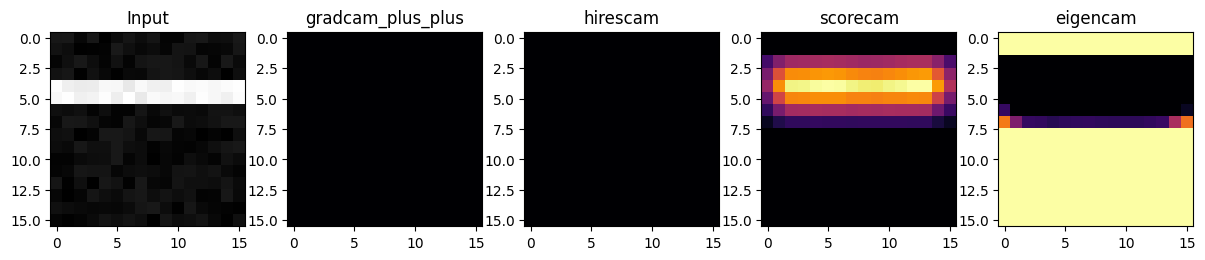

IG shape: (2, 1, 16, 16) EigenCAM is class-independent.


TreeSHAP shape: (2, 3, 2)


In [2]:
import matplotlib.pyplot as plt
from autoexplain.demo import trained_demo, bars
from autoexplain.backends import captum_attribute, cam_attribute, shap_explain
from sklearn.tree import DecisionTreeClassifier
net = trained_demo()
images, labels = bars(2, seed=99)
ig = captum_attribute(net, images, method="integrated_gradients", target=0, n_steps=16)
maps = {name: cam_attribute(net, images[:1], layers=["features.3"], method=name, target=0)[0]
        for name in ["gradcam_plus_plus", "hirescam", "scorecam", "eigencam"]}
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(images[0, 0], cmap="gray"); axes[0].set_title("Input")
for ax, (name, cam) in zip(axes[1:], maps.items()):
    ax.imshow(cam, cmap="inferno"); ax.set_title(name)
plt.tight_layout(); plt.show()
print("IG shape:", tuple(ig.shape), "EigenCAM is class-independent.")
x = np.random.randn(48, 3); y = (x[:, 0] > 0).astype(int)
tree = DecisionTreeClassifier(max_depth=2, random_state=7).fit(x, y)
explanation = shap_explain(tree, x[:2], background=x[:12])
print("TreeSHAP shape:", explanation.values.shape)
assert np.isfinite(explanation.values).all()


In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
rss_mib = rss / (1024**2 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                 "kernel_lifetime_peak_rss_mib": round(rss_mib, 2),
                 "memory_scope": "kernel only, including imports; not aggregate system memory"}))


{"tutorial_compute_wall_seconds": 2.219, "kernel_lifetime_peak_rss_mib": 665.8, "memory_scope": "kernel only, including imports; not aggregate system memory"}
